In [1]:
from typing import Union

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sqlalchemy import create_engine

In [2]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

connect_alchemy = "postgresql+psycopg2://%s:%s@%s/%s" % (
    config['DATABASE']['USERNAME'],
    config['DATABASE']['PASSWORD'],
    config['DATABASE']['HOST'],
    config['DATABASE']['DB']
)
engine = create_engine(connect_alchemy)

In [3]:
df = pd.read_sql_query('select * from price',con=engine, parse_dates=[0], index_col='datetime')
df.head()

,close,high,low,open,volume,instrument
datetime,,,,,,
2014-01-24,114.00,115.35,113.00,113.15,5737135,HINDALCO
2014-01-27,111.10,112.70,109.30,112.00,8724577,HINDALCO
2014-01-28,113.80,115.00,109.75,110.00,4513345,HINDALCO
2014-01-29,111.75,114.75,111.15,114.50,4713458,HINDALCO
2014-01-30,108.10,110.70,107.60,110.20,5077231,HINDALCO


## Trading Strategy

- Compute the 1 week $S_1$, 2 week $S_2$ , 3 week $S_3$ and 4 week $S_4$ slope for the closing price. $S_i \in \{-1,1\}$
- Add the slopes of all the signals and compute an aggregate signal $S_{agg} = S_1 + S_2 + S_3 + S_4$
- Create positions as $\frac{S_{agg}}{4}$

### Trading Rules
- Enter Full/Partial Long position if we get a +4/+2 and Short if we get -4/-2
- Exit when we hit a SL or we get a 0 signal or the sign reverses.

In [98]:
def bollinger_bands_signal(close_price:pd.Series, period:int, multiplier:float=2):
    bb = close_price.to_frame()
    bb['mean'] = close_price.rolling(period).mean()
    bb['std'] = multiplier*(close_price.rolling(period).std())
    bb['upper_band'] = bb['mean'] + (bb['std'])
    bb['lower_band'] = bb['mean'] - (bb['std'])
    bb = bb.dropna()
    
    signals = pd.DataFrame(index=bb.index)
    up_cross = (bb['close'].shift(1) < bb['upper_band'].shift(1)) & (bb['close'] > bb['upper_band'])
    up_exit = (bb['close'].shift(1) > bb['upper_band'].shift(1)) & (bb['close'] < bb['upper_band'])
    down_cross = (bb['close'].shift(1) > bb['lower_band'].shift(1)) & (bb['close'] < bb['lower_band'])
    down_exit = (bb['close'].shift(1) < bb['lower_band'].shift(1)) & (bb['close'] > bb['lower_band'])
    exit = up_exit | down_exit
    bb['-1'] = np.nan
    bb['1'] = np.nan
    bb['0'] = np.nan
    bb['1'].loc[up_cross] = 1
    bb['-1'].loc[down_cross] = 1
    bb['0'].loc[exit] = 1
#     exit_cross = ((bb['-1'].shift(1) == 1) & (bb['close'] >= bb['mean'])) | ((bb['1'].shift(1) == 1)& (bb['close'] <= bb['mean']))
    print(exit.sum())
    
    
    
    signals = bb[['1', '-1', '0']].idxmax(1)
    signals = signals.fillna(method='ffill')
    signals = signals.fillna('0')
    signals = signals.astype(int)
    bb['signal'] = signals
    return bb
    

def get_signal(close:pd.Series)->pd.DataFrame:
    signals = pd.DataFrame()
    def np_slope(data):
        return np.polyfit(np.arange(len(data)),data.values,1)[0]
    signals['1_week_signal']= close.rolling(5).apply(np_slope,raw=False)
    signals['2_week_signal']= close.rolling(10).apply(np_slope,raw=False)
    signals['3_week_signal']= close.rolling(15).apply(np_slope,raw=False)
    signals['4_week_signal']= close.rolling(20).apply(np_slope,raw=False)
    signals = signals.dropna()
    signals_sign = np.sign(signals)
    signals['signal'] = signals_sign.sum(1).astype(int)
    return signals
signals = get_signal(df.close)

In [99]:
signals = bollinger_bands_signal(df.close, 24)

69


In [100]:
returns = df.close.pct_change() * signals['signal']

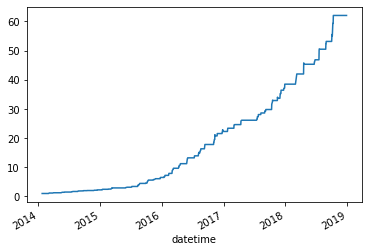

In [101]:
returns = returns.fillna(0)
(1+returns).cumprod().plot()

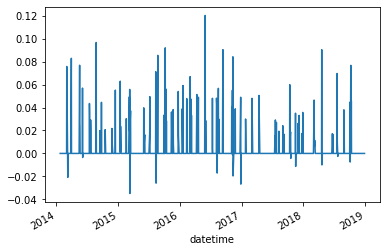

In [109]:
returns.plot()

In [103]:
signals

,close,mean,std,upper_band,lower_band,-1,1,0,signal
datetime,,,,,,,,,
2014-02-26,98.40,103.827083,10.789285,114.616369,93.037798,NaN,NaN,NaN,0
2014-02-28,105.35,103.466667,9.913218,113.379884,93.553449,NaN,NaN,NaN,0
2014-03-03,105.60,103.237500,9.418633,112.656133,93.818867,NaN,NaN,NaN,0
2014-03-04,113.60,103.229167,9.379901,112.609067,93.849266,NaN,1.0,NaN,1
2014-03-05,115.75,103.395833,10.124440,113.520273,93.271394,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...
2018-12-21,224.00,222.883333,10.370722,233.254056,212.512611,NaN,NaN,NaN,0
2018-12-24,217.85,222.191667,9.310941,231.502608,212.880726,NaN,NaN,NaN,0
2018-12-26,218.60,222.052083,9.425796,231.477880,212.626287,NaN,NaN,NaN,0


In [93]:
signals['signal'].value_counts()

 1    601
-1    588
 0      3
Name: signal, dtype: int64

In [104]:
buy = signals[signals['1']==1]
sell = signals[signals['-1']==1]
exit = signals[signals['0']==1]

In [105]:
close = df.close
buy_price = close.loc[buy.index]
sell_price = close.loc[sell.index]
exit_price = close.loc[exit.index]

In [106]:
exit_price 

datetime
2014-03-11    117.40
2014-04-01    138.20
2014-05-22    155.10
2014-06-09    169.60
2014-07-18    184.60
               ...  
2018-08-29    236.85
2018-08-31    237.95
2018-10-05    241.05
2018-10-09    224.25
2018-10-12    226.70
Name: close, Length: 69, dtype: float64

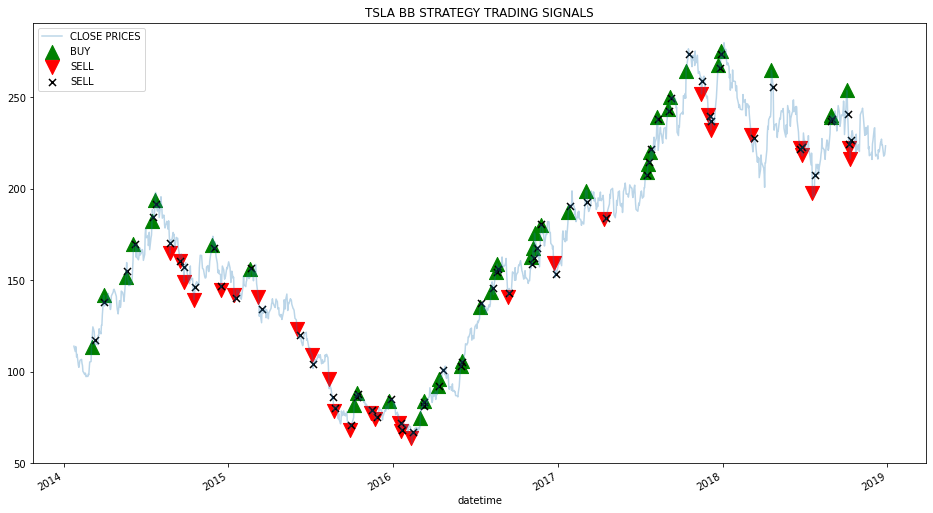

In [108]:
plt.figure(figsize=(16,9))
df.close.plot(label = 'CLOSE PRICES', alpha = 0.3)
plt.scatter(buy_price.index, buy_price, marker = '^', color = 'green', label = 'BUY', s = 200)
plt.scatter(sell_price.index, sell_price, marker = 'v', color = 'red', label = 'SELL', s = 200)
plt.scatter(exit_price.index, exit_price, marker = 'x', color = 'k', label = 'SELL', s = 50)
plt.title('TSLA BB STRATEGY TRADING SIGNALS')
plt.legend(loc = 'upper left')
plt.show()

In [85]:
signals.head()

,1_week_signal,2_week_signal,3_week_signal,4_week_signal,agg_signal
datetime,,,,,
2014-02-20,-4.750000e-01,-1.082727,-0.660714,-0.804173,-4
2014-02-21,-3.650000e-01,-0.970303,-0.592321,-0.766391,-4
2014-02-24,-4.900000e-01,-0.736061,-0.660714,-0.752669,-4
2014-02-25,-5.636427e-15,-0.464848,-0.702500,-0.656504,-4
2014-02-26,3.250000e-01,-0.215758,-0.689821,-0.575865,-2


In [105]:
class Backtester:
    def __init__(self, price_df:pd.DataFrame, stoploss:Union[float, bool], start_date: str):
        self.price = price_df.close
        self.SL = stoploss
        self.start_date = pd.to_datetime(start_date)
        self.current_position = None
        self.previous_signal = None
        self.signals = self.signal_generator(self.price)
        self.trades = []
        
    def create_position(self, date:Union[pd.Timestamp, str], 
                        price:float, side:str, size:int, stop:float=np.nan):
        self.trades.append({'date':date, 'price':price, 'side':side, 
                            'size':size/4, 'stop':stop})
        
    def signal_generator(self, price:pd.Series):
        signals = get_signal(price)['signal']
        for signal in signals.iteritems(): 
            yield signal
    
    def check_stoploss(self, date:Union[pd.Timestamp, str], price:float):
        this_position = self.trades[-1] 
        if this_position['side'] ==  'BUY' and price <= this_position['stop']:
            self.create_position(date, price=price, side='EXIT SL', size=0)
            self.current_position = None
        elif this_position['side'] ==  'SELL' and price >= this_position['stop']:
            self.create_position(date, price=price, side='EXIT SL', size=0)
            self.current_position = None
    
    def check_trade(self, date:Union[pd.Timestamp, str], signal:int, price:float):
        SL=None
        if self.current_position is None:
            if signal > 0:
                #long signal
                if self.SL:
                    SL = price - price*self.SL 
                self.create_position(date, price=price, side='BUY', size=signal, stop=SL)
                self.current_position = 1
            elif signal < 0:
                #short signal
                if self.SL:
                    SL = price + price*self.SL 
                self.create_position(date, price=price, side='SELL', size=abs(signal), stop=SL)
                self.current_position = -1
        else:
            if (self.current_position == 1 and signal < 0) or (self.current_position == -1 and signal > 0) or (signal == 0):
                self.create_position(date, price=price, side='EXIT', size=0)
                self.current_position = None
        
    def run(self):
        cdate = self.start_date
        while True:
            try:
                cdate, current_signal = next(self.signals)
                price =self.price.loc[cdate]
                self.check_trade(cdate, current_signal, price)
                if self.SL and self.current_position is not None:
                    self.check_stoploss(cdate, price)
                self.previous_signal = current_signal
                cdate = cdate + pd.Timedelta(1, 'D')
            except StopIteration:
                break
                

In [127]:
backtest = Backtester(df, 0.01, '2014-02-20')
backtest.run()

In [128]:
trades_book = pd.DataFrame(backtest.trades)
trades_book = trades_book.set_index('date')
trades_book.head()

,price,side,size,stop
date,,,,
2014-02-20,97.35,SELL,1.0,98.3235
2014-02-25,98.80,EXIT SL,0.0,NaN
2014-02-26,98.40,SELL,0.5,99.3840
2014-02-28,105.35,EXIT,0.0,NaN
2014-03-04,113.60,BUY,0.5,112.4640


In [129]:
def trades_return(trades):
    realized_pnl = pd.Series(name='realized_pnl')
    trade_returns = pd.Series(name='returns')
    for i in range(0, len(trades), 2):
        trade = trades.iloc[i]
        exit = trades.iloc[i+1]
        entry_price = trade['price']
        side = trade['side']
        exit_price = exit['price']
        date = exit.name
        if side == 'SELL':
            realized_pnl[date] = (entry_price - exit_price)
            trade_returns[date] = (entry_price/exit_price) - 1
        elif side == 'BUY':
            realized_pnl[date] = (exit_price - entry_price)
            trade_returns[date] = (exit_price/entry_price) - 1
    return realized_pnl, trades_return
        
pnl, returns = trades_return(trades_book)

<ipython-input-129-c32da64b2b2d>:2: DeprecationWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  realized_pnl = pd.Series(name='realized_pnl')
<ipython-input-129-c32da64b2b2d>:3: DeprecationWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  trade_returns = pd.Series(name='returns')


In [138]:
df.pivot_table

<bound method DataFrame.pivot_table of              close    high     low    open   volume instrument
datetime                                                      
2014-01-24  114.00  115.35  113.00  113.15  5737135   HINDALCO
2014-01-27  111.10  112.70  109.30  112.00  8724577   HINDALCO
2014-01-28  113.80  115.00  109.75  110.00  4513345   HINDALCO
2014-01-29  111.75  114.75  111.15  114.50  4713458   HINDALCO
2014-01-30  108.10  110.70  107.60  110.20  5077231   HINDALCO
...            ...     ...     ...     ...      ...        ...
2018-12-21  224.00  227.45  221.80  224.25  6933691   HINDALCO
2018-12-24  217.85  224.00  216.95  224.00  4667022   HINDALCO
2018-12-26  218.60  219.80  212.90  213.85  6554865   HINDALCO
2018-12-27  220.60  223.90  219.60  221.40  7947144   HINDALCO
2018-12-28  223.50  226.05  221.00  221.00  5074920   HINDALCO

[1215 rows x 6 columns]>

In [139]:
df = pd.DataFrame({"A": ["foo", "foo", "foo", "foo", "foo",
                         "bar", "bar", "bar", "bar"],
                   "B": ["one", "one", "one", "two", "two",
                         "one", "one", "two", "two"],
                   "C": ["small", "large", "large", "small",
                         "small", "large", "small", "small",
                         "large"],
                   "D": [1, 2, 2, 3, 3, 4, 5, 6, 7],
                   "E": [2, 4, 5, 5, 6, 6, 8, 9, 9]})

In [140]:
table = pd.pivot_table(df, values='D', index=['A', 'B'],
                    columns=['C'], aggfunc=np.sum)

In [141]:
table

C        large  small
A   B                
bar one    4.0    5.0
    two    7.0    6.0
foo one    4.0    1.0
    two    NaN    6.0

In [ ]:
df.pivot_table()